## Google drive ko mount krne ke lie

In [16]:
import os
import numpy as np
import cv2    # opencv-python to be installed
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
# from torchsummary import summary
from tqdm import tqdm

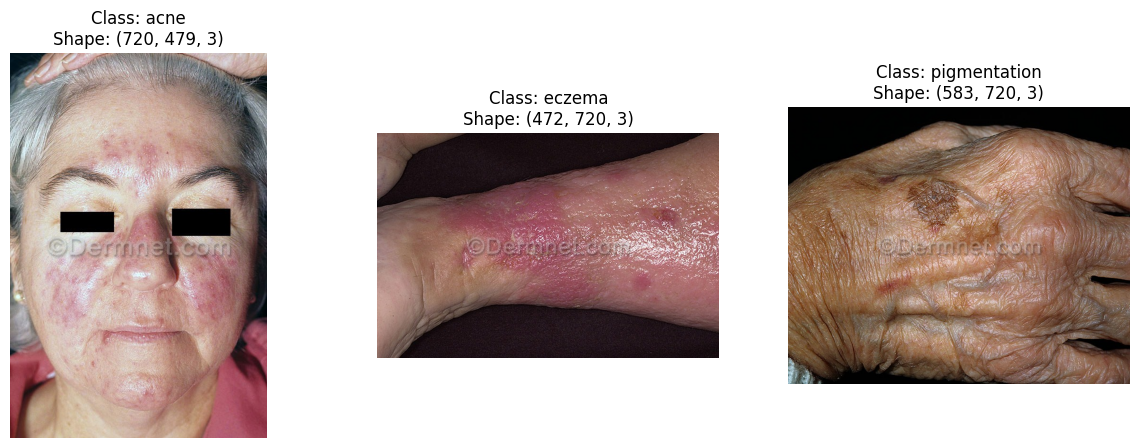

In [17]:

def visualize_random_images(data_dir, classes):
    plt.figure(figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        # Folder ke andar ki files ki list
        folder_path = os.path.join(data_dir, class_name)
        img_name = random.choice(os.listdir(folder_path))
        img_path = os.path.join(folder_path, img_name)
        
        # Plotting
        plt.subplot(1, 3, i+1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.title(f"Class: {class_name}\nShape: {img.shape}")
        plt.axis('off')
    
    plt.show()

# Visualize Train images
visualize_random_images('Train', ['acne', 'eczema', 'pigmentation'])

In [18]:
# EfficientNet-B0 standard 224x224 input mangta hai
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    # 1. Random Flip: Skin images kisi bhi direction se ho sakti hain
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15), 
    
    # 2. ColorJitter: Pollution aur lighting variability ke liye
    # Brightness aur contrast thoda badlenge taaki model robust bane
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    
    # 3. Conversion to Tensor
    transforms.ToTensor(),
    
    # 4. Normalization: EfficientNet-B0 ImageNet weights use karta hai
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [19]:
img.shape

NameError: name 'img' is not defined

In [13]:
# Datasets define karo
train_dataset = datasets.ImageFolder(root='Train', transform=train_transform)
test_dataset = datasets.ImageFolder(root='Test', transform=test_transform)

# Print Summary
print(f"✅ Training images found: {len(train_dataset)}")
print(f"✅ Testing images found: {len(test_dataset)}")
print(f"✅ Class to Index mapping: {train_dataset.class_to_idx}")

# DataLoaders: Shuffling train data is must!
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

✅ Training images found: 2643
✅ Testing images found: 764
✅ Class to Index mapping: {'acne': 0, 'eczema': 1, 'pigmentation': 2}


In [14]:
# DataLoader se ek batch nikalna
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Shape print karna
print(f"Batch Shape: {images.shape}") 
# Output aayega: torch.Size([32, 3, 224, 224])

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch Shape: torch.Size([32, 3, 224, 224])
